# Model selection

Model selection by 5-fold cross validation.

In [ ]:
import torch
from torch.distributions import Normal
import gpytorch
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import UnwhitenedVariationalStrategy
from gpytorch.means import Mean, ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

try:
    import sys
    import os

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.linspace(0.1, 0.9, 9).to(device)
true_quantiles = mean(x) + std(x) * Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

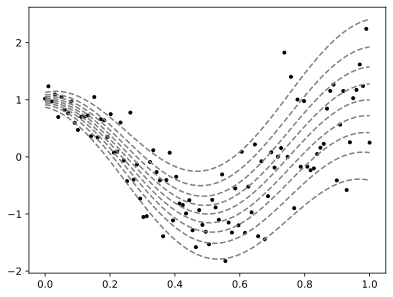

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

In [ ]:
K = 5
N = x.shape[0]  # 100
fold_size = N // K  # 20
M = N - fold_size

x_train_list, y_train_list, x_test_list, y_test_list = [], [], [], []
for k in range(K):
    test_mask = torch.zeros(N, dtype=torch.bool)
    test_mask[k * fold_size : (k + 1) * fold_size] = True
    x_train_list.append(x[~test_mask])
    y_train_list.append(y[~test_mask])
    x_test_list.append(x[test_mask])
    y_test_list.append(y[test_mask])

x_train_cv = torch.stack(x_train_list).to(device)
y_train_cv = torch.stack(y_train_list).to(device)
x_test_cv = torch.stack(x_test_list).to(device)
y_test_cv = torch.stack(y_test_list).to(device)

inducing_points = x_train_cv.detach().clone()  # [K, M, D]